**Scenario** 

Saya dikontrak sebagai Data Analyst oleh pemilik Kedai Kopi Aroma Jaya untuk memecah anomali operasional di Cabang Sudirman. Pemilik menemukan kejanggalan: secara visual terjadi antrean pelanggan yang sangat panjang, namun laporan dashboard menunjukkan pendapatan yang stagnan. Di sisi lain, pemilik telah meningkatkan pasokan bahan baku dalam jumlah besar sebagai antisipasi keramaian, yang justru berujung pada kerugian akibat penumpukan stok. Proyek analisis data transaksi Poin of Sales (Januari-Juni 2026) ini bertujuan untuk mengidentifikasi akar masalah antrean, memetakan perilaku pembelian konsumen, serta menyusun rekomendasi strategi optimasi operasional dan efisiensi stok agar kerugian serupa tidak terulang kembali.

**Define Question**

Untuk membantu sang owner, saya memerlukan beberapa informasi yang berhubungan dengan antrian panjang. Sehingga, pertanyaan yang saya definisikan adalah sebagai berikut:
1. Bagaimana tren penjualan Aroma Jaya dari waktu ke waktu?
2. Hari apa saja dalam seminggu yang cenderung paling banyak penjualan?
3. Waktu/jam berapa saja yang cenderung paling banyak penjualan?

let's dive in!

### Import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# mengatur tampilan grafik
sns.set_theme(
    # warna putih warna yang paling bersih
    style="white", 
    rc={
        # membuat kotak pembungkus grafik hilang
        "axes.spines.top": False,
        "axes.spines.bottom": False,
        "axes.spines.right": False,
        "axes.spines.left": False,

        # mengatur agar warna labelnya abu abu, 
        # dan jarak label dengan ticksnya
        "axes.labelcolor": "grey",
        "xtick.color": "grey",
        "ytick.color": "grey",
        "axes.labelpad": 10,

        # mengatur warna, posisi, jarak, dan ukuran judul grafiknya
        "axes.titlecolor": "black", 
        "axes.titlelocation": "left", 
        "axes.titlepad": 15,            
        "axes.titlesize": 15
    }
)

### Load & filter data

In [2]:
# load data yang sudah dibersihkan pada tahap prepartion data 
data = pd.read_csv('cleaned_data.csv')
data.head()

,transaction_id,transaction_date,store_location,product_id,product_name,product_category,quantity,unit_price,tipe_order,omzet,month,day,hour
0,TX27199,2026-02-21,Gading Serpong (Residential),107,Es Teh Manis,Non-Coffee,1,10000,Takeaway,10000,February,Saturday,21
1,TX15186,2026-04-03,Sudirman (Office),103,Café Latte,Coffee,2,30000,Takeaway,60000,April,Friday,8
2,TX22510,2026-03-20,Gading Serpong (Residential),104,Matcha Latte,Non-Coffee,5,28000,Dine-in,140000,March,Friday,17
3,TX27134,2026-06-20,Senopati (Hangout),107,Es Teh Manis,Non-Coffee,1,10000,Dine-in,10000,June,Saturday,15
4,TX35561,2026-02-21,Senopati (Hangout),102,Americano,Coffee,1,25000,Takeaway,25000,February,Saturday,18


In [3]:
# filter hanya data dari cabang Sudirman
data = data[data['store_location'] == 'Sudirman (Office)']
len(data)

20530

### Data info and basic statistics

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20530 entries, 1 to 43805
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    20530 non-null  object
 1   transaction_date  20530 non-null  object
 2   store_location    20530 non-null  object
 3   product_id        20530 non-null  int64 
 4   product_name      20530 non-null  object
 5   product_category  20530 non-null  object
 6   quantity          20530 non-null  int64 
 7   unit_price        20530 non-null  int64 
 8   tipe_order        20530 non-null  object
 9   omzet             20530 non-null  int64 
 10  month             20530 non-null  object
 11  day               20530 non-null  object
 12  hour              20530 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 2.2+ MB


#### Numerical Statistic

In [5]:
data.describe()

,product_id,quantity,unit_price,omzet,hour
count,20530.000000,20530.000000,20530.000000,20530.000000,20530.000000
mean,103.018363,1.402094,22626.838773,31720.409157,13.742572
std,2.131030,0.809899,5481.875831,20332.375228,4.574413
min,101.000000,1.000000,10000.000000,10000.000000,7.000000
25%,101.000000,1.000000,22000.000000,22000.000000,9.000000
50%,102.000000,1.000000,22000.000000,25000.000000,13.000000
75%,105.000000,2.000000,25000.000000,30000.000000,18.000000
max,108.000000,5.000000,30000.000000,150000.000000,21.000000


#### Categorical Statistic

In [6]:
data.describe(include='object')

,transaction_id,transaction_date,store_location,product_name,product_category,tipe_order,month,day
count,20530,20530,20530,20530,20530,20530,20530,20530
unique,20530,180,1,8,4,2,6,7
top,TX12809,2026-02-28,Sudirman (Office),Es Kopi Susu Gula Aren,Coffee,Dine-in,May,Saturday
freq,1,213,20530,7104,13611,10624,3658,4566


### 1.Bagaimana tren penjualan Aroma Jaya dari waktu ke waktu?

#### Visualisai

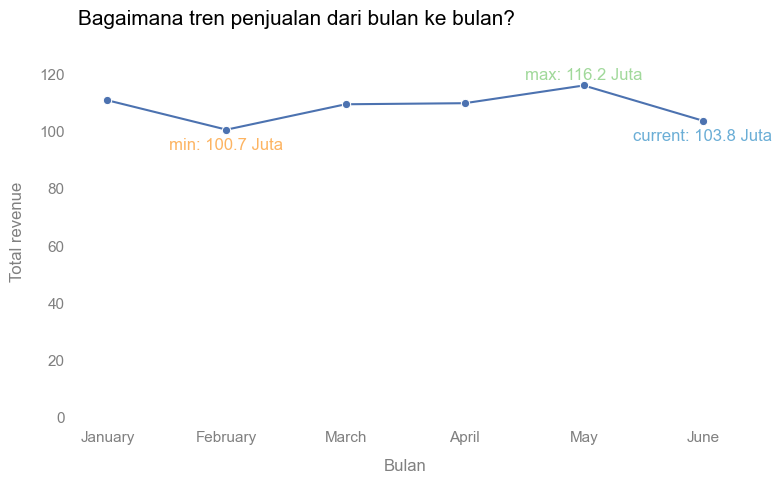

In [7]:
# aggregat total transaksi per bulannya
tren_transaksi = data.groupby('month').agg(
    total_revenue = ('omzet','sum')
).reset_index()

# mengubah angkanya menjadi lebih mudah dibaca
tren_transaksi['total_revenue'] = tren_transaksi['total_revenue']/1000000

# mengurutkan hasilnya berdasarkan urutan nama bulan
ordered_month = ['January','February','March','April','May','June']
tren_transaksi['month'] = pd.Categorical(tren_transaksi['month'], categories=ordered_month, ordered=True)
tren_transaksi = tren_transaksi.sort_values('month').reset_index(drop=True)

# ambil data max, min, dan current
idx_max = tren_transaksi['total_revenue'].idxmax()
idx_min = tren_transaksi['total_revenue'].idxmin()
idx_current = tren_transaksi[tren_transaksi['month'] == 'June' ].index[0]

# membuat grafik lineplot
plt.figure(figsize=(8,5))
ax = sns.lineplot(tren_transaksi, x='month', y='total_revenue', marker='o')

# membuat text di dalam grafik 
# membuat teks jumlah transaksi untuk bulan dengan transaksi paling banyak
row_max = tren_transaksi.iloc[idx_max]
ax.text(
    x = idx_max, 
    y = row_max['total_revenue']+2,
    s = f"max: {row_max['total_revenue']:.1f} Juta", 
    color = '#A1D99B', 
    ha = 'center'
)

# membuat teks jumlah transaksi untuk bulan dengan transaksi paling sedikit
row_min = tren_transaksi.iloc[idx_min]
ax.text(
    x = idx_min, 
    y = row_min['total_revenue']-7,
    s = f"min: {row_min['total_revenue']:.1f} Juta", 
    color = '#FDB462', 
    ha = 'center'
)

# membuat teks jumlah transaksi untuk bulan terbaru
row_current = tren_transaksi.iloc[idx_current]
ax.text(
    x = idx_current, 
    y = row_current['total_revenue']-7,
    s = f"current: {row_current['total_revenue']:.1f} Juta", 
    color = '#6baed6',  
    ha = 'center'
)

# mengatur limit angka sumbu y, untuk menghindari kesalahan interpretasi
ax.set_ylim(bottom=0, top=130)

# mengatur judul, label x, dan label y pada grafik
ax.set_title('Bagaimana tren penjualan dari bulan ke bulan?')
ax.set_xlabel('Bulan')
ax.set_ylabel('Total revenue')

plt.tight_layout()
plt.show()

#### Informasi

**Informasi yang didapat**
- seperti yang dikatakan oleh sang owner. laporan transaksi per bulannya ternyata memang lumayan datar, malah menurun di bulan terbaru ini
- rentang revenue antara 100.7 - 116.2 Juta (selisih 16 jt-an). Bukan selisih yang begitu besar, mengingat ini adalah perbandingan transaksi dalam perbulan

### 2.Hari apa saja dalam seminggu yang cenderung paling banyak penjualan?

#### Visualisai

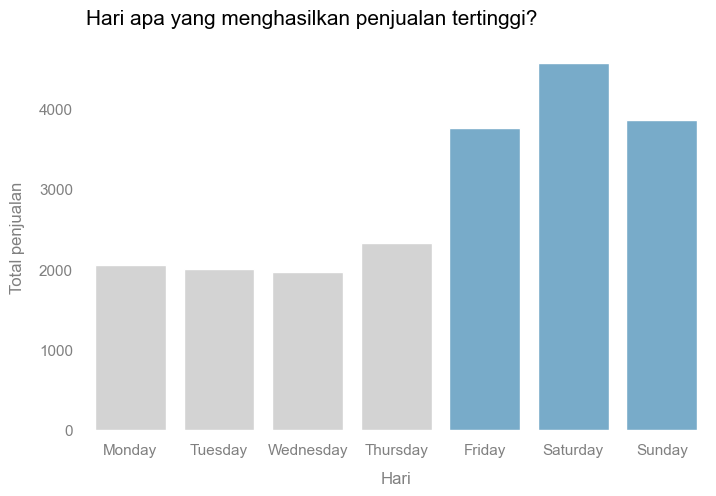

In [8]:
# membuat list untuk mengurutkan hari
urutan_hari = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# groupby total transkasi
# berdasarkan hari dalam seminggu
group = data.groupby('day').agg(
    orders = ('quantity','count')
).reset_index()

#urutkan nama hari
group['day'] = pd.Categorical(group['day'], categories=urutan_hari, ordered=True)
group = group.sort_values('day')

# Hari yang masuk top_3 diberi warna biru tua ('navy'), sisanya abu-abu ('lightgrey')
top_3_days = group.nlargest(3, 'orders')['day'].tolist()
warna_palette = {hari: '#6baed6' if hari in top_3_days else 'lightgrey' for hari in group['day']}

# membuat lineplot untuk transaksi bulan januari
plt.figure(figsize=(8,5))
ax = sns.barplot(group, x='day', y='orders', hue='day', palette=warna_palette, legend=False)
ax.set_title('Hari apa yang menghasilkan penjualan tertinggi?')
ax.set_xlabel('Hari')
ax.set_ylabel('Total penjualan')

plt.show()

#### Informasi

**Informasi yang didapat**
- Berdasarkan hasil barplot diatas, Hari yang paling banyak penjualan adalah hari Jumat, Sabtu, dan Minggu.

Apakah pola ini terjadi setiap bulan? atau ada lonjakan di satu bulan tertentu yang menyebabkan hari tersebut lebih banyak penjualan daripada hari yang lain?

#### Visualisasi

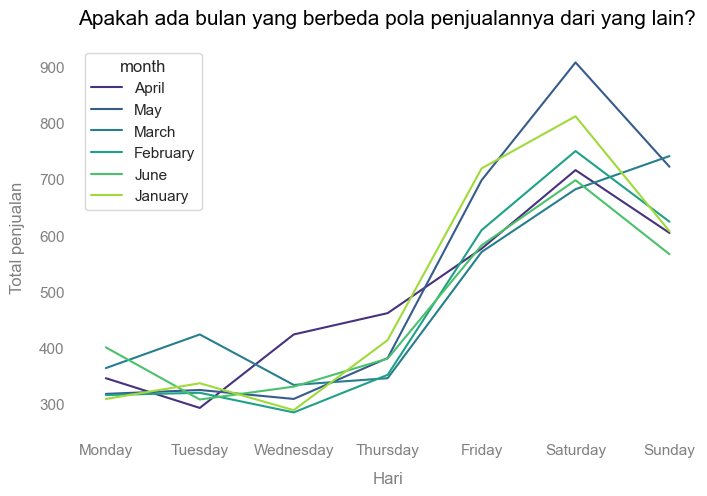

In [9]:
# membuat list untuk mengurutkan hari
urutan_hari = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# groupby total transkasi
# berdasarkan hari dalam seminggu
group = data.groupby(['month','day']).agg(
    orders = ('quantity','count')
).reset_index()

#urutkan nama hari
group['day'] = pd.Categorical(group['day'], categories=urutan_hari, ordered=True)
group = group.sort_values('day')

# membuat lineplot untuk transaksi bulan januari
plt.figure(figsize=(8,5))
ax = sns.lineplot(group, x='day', y='orders', hue='month', palette='viridis', legend=True)
ax.set_title('Apakah ada bulan yang berbeda pola penjualannya dari yang lain?')
ax.set_xlabel('Hari')
ax.set_ylabel('Total penjualan')

plt.show()

#### Informasi

**Informasi yang didapat**
- Grafik tersebut juga menunjukkan bahwa ada pola berulang yang sama setiap bulannya, sehingga bisa dibedakan menjadi 2 kategori:
  1. Senin-Kamis (sedikit transaksi)
  2. Jumat-Minggu (banyak transaksi)

### 3.Waktu/jam berapa saja yang cenderung paling banyak penjualan?

Mari kita cek dalam dimensi per hari dalam seminggu

#### Visualisai

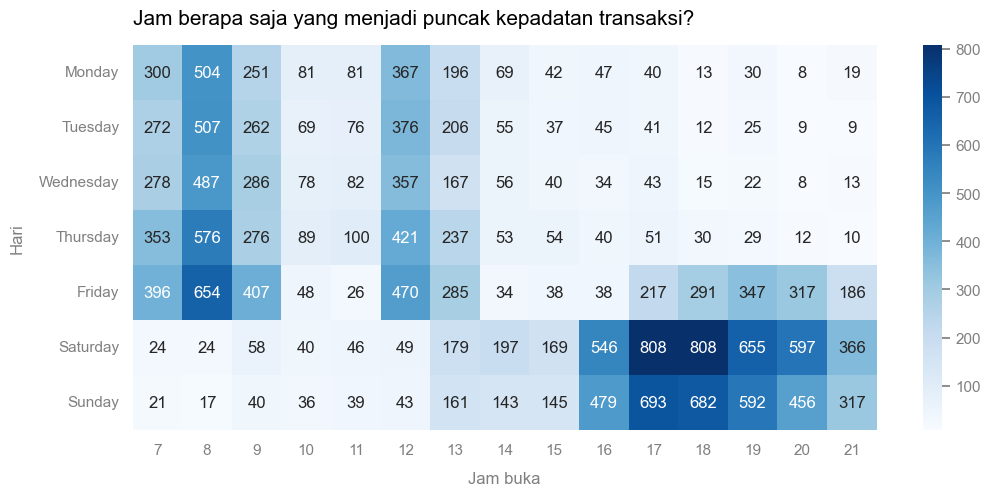

In [10]:
# menggunakan heatmap karena ada 3 kolom (day, hour, total_transaksi)
# pivot tabel untuk mendapatkan total penjualan per hari per jam
pivot_waktu = data.pivot_table(
    index='day',
    columns='hour',
    values='quantity',
    aggfunc='count'
).reindex(index=urutan_hari) # mengurutkan index hari agar sesusai urutan hari

# membuat heatmap
plt.figure(figsize=(12,5))
ax = sns.heatmap(pivot_waktu, cmap='Blues', annot=True, fmt='g')
ax.set_title('Jam berapa saja yang menjadi puncak kepadatan transaksi?')
ax.set_xlabel('Jam buka')
ax.set_ylabel('Hari')

plt.show()

#### Informasi

**Informasi yang didapat:**
- Terdapat pola berulang yang terjadi per jamnya, dimana:
  1. Senin-Jumat pukul 7-9 pagi dan pukul 12-13 siang adalah jam-jam paling banyak penjualan diantara jam lainnya
  2. Khusus hari Jumat, di jam 5-21, toko kembali ramai dan menghasilkan banyak penjualan
  3. Sabtu & Minggu dimulai pukul 13-21 sudah mulai ramai yang puncaknya di pukul 16-20

untuk memvalidasi hal ini. mari kita perdalam lagi dimensinya. kita akan melakukan perbandingan per hari pada masing-masing bulan. Tujuannya adalah untuk mengetahui apakah ada pola yang berbeda? atau semuanya merata?

#### Visualisai

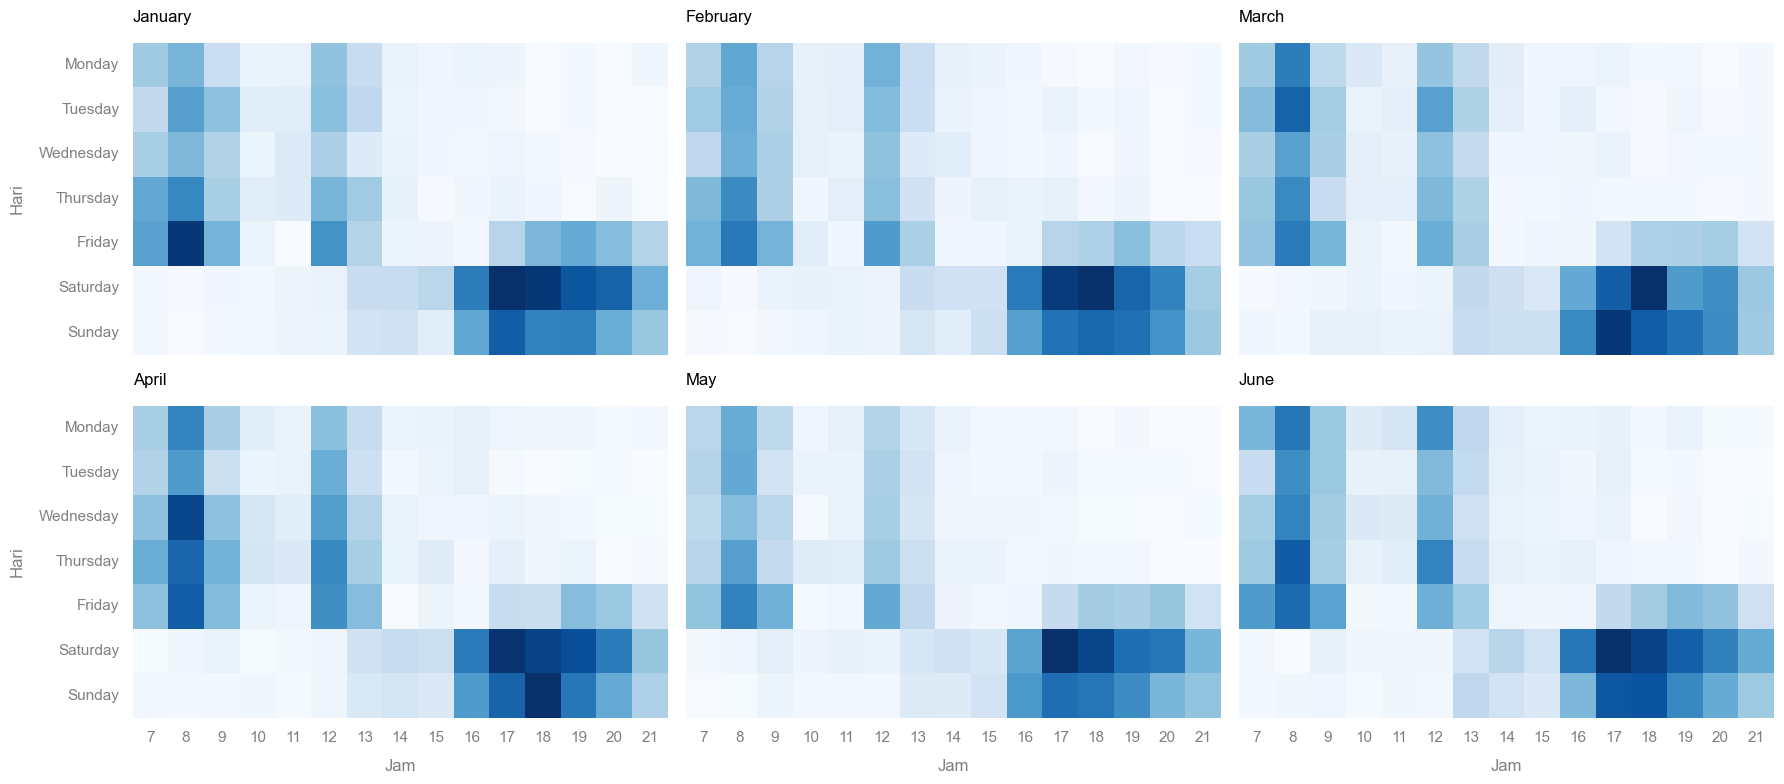

In [11]:
urutan_hari = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
urutan_bulan = ['January','February','March','April','May','June']

group_data = data.groupby(['month', 'day', 'hour']).agg(
    orders=('quantity', 'count')
).reset_index()

group_data['day'] = pd.Categorical(group_data['day'], categories=urutan_hari, ordered=True)
group_data['month'] = pd.Categorical(group_data['month'], categories=urutan_bulan, ordered=True)

def draw_heatmap(*args, **kwargs):
    data_sub = kwargs.pop('data')
    # Pivot sub-data untuk bulan ini
    pivot = data_sub.pivot_table(index='day', columns='hour', values='orders', aggfunc='sum', observed=False)
    # Reindex untuk memastikan hari berurutan
    pivot = pivot.reindex(index=urutan_hari)
    sns.heatmap(pivot, cmap='Blues', annot=False, cbar=False, **kwargs)

g = sns.FacetGrid(group_data, col="month", col_wrap=3, height=4, aspect=1.5)
g.map_dataframe(draw_heatmap)

g.set_titles("{col_name}")
g.set_axis_labels("Jam", "Hari")
plt.tight_layout()
plt.show()

#### Informasi

**Informasi yang didapat**
- semua Hari dari masing-masing bulan memberikan pola berulang yang sama.
- Senin-Jumat: jam 7-9 pagi, jam 12-13 siang
- khsusu Jumat: jam 17-21
- Sabtu-Minggu: mulai ramai dari jam 13, puncaknya dari jam 16-21

### Kesimpulan

**Informasi yang didapat**
1. Bagaimana tren penjualan Aroma Jaya dari waktu ke waktu?
   - seperti yang dikatakan oleh sang owner. laporan transaksi per bulannya ternyata memang lumayan datar.
2. Hari apa saja dalam seminggu yang cenderung paling banyak penjualan?
   - Hari yang paling banyak penjualan setiap bulannya ada di hari Jumat, Sabtu, dan Minggu.
3. Waktu/jam berapa saja yang cenderung paling banyak penjualan?
   - Senin-Jumat: jam 7-9 & 12-13
   - Khusus hari Jumat: jam 17-21 
   - Sabtu & Minggu: dimulai dari jam 13, puncaknya di jam 16-21